# Lesion Analysis

## TDT Pipeline - Peter Yazdi

Welcome to the lesion analysis script. 

For any concerns/help please email pyazdi@bbcrc.ca

In [1]:
import matplotlib.pyplot as plt
import SimpleITK as sitk
import nibabel as nib
import os
from json_minify import json_minify
import json
import numpy as np
from scipy.ndimage import zoom
import torch
from scipy.optimize import curve_fit

import matplotlib as mpl
import matplotlib.pyplot as plt


In [2]:
output_dir = '/home/jhubadmin/Theranostic-Virtual-Patient-Pipeline/full_lesions_test_CT_0'

config_path = os.path.join(output_dir, 'config.json')

with open(config_path, 'r') as f: # minify JSON to remove comments and trailing commas
    config = json.loads(json_minify(f.read()))


In [3]:
spect_preproc_dir = os.path.join(output_dir, config['subdir_names']['spect_preprocessing'])
pbpk_dir = os.path.join(output_dir, config['subdir_names']['pbpk'])
spect_sim_dir = os.path.join(output_dir, config['subdir_names']['spect_simulation'])

spect_preproc_prefix = config['spect_preprocessing']['name']
pbpk_prefix = config['pbpk']['name']
spect_sim_prefix = config['spect_simulation']['name']

TDT ROI unique values: [0 1 2 3 4 5 6 7 8]
TDT ROI shape: (335, 512, 512)
Number of lesions: 18


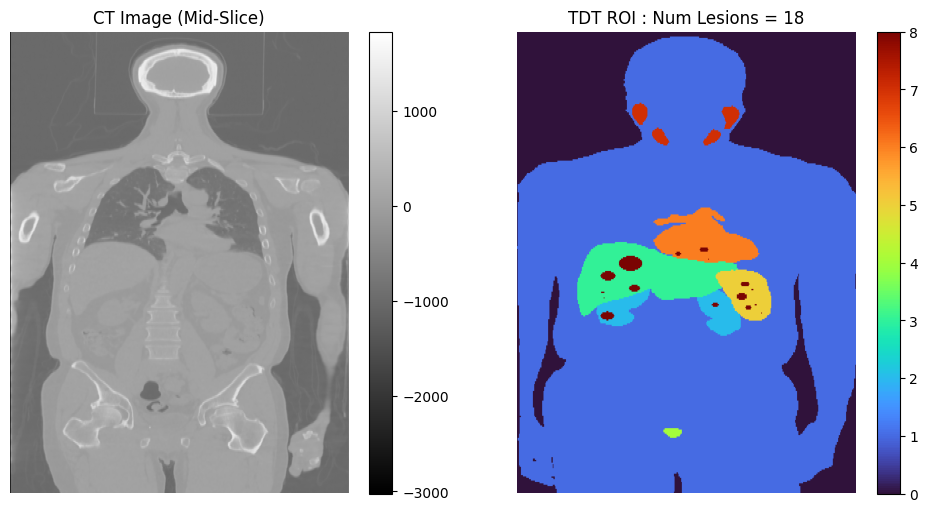

In [4]:
ct_path = os.path.join(spect_preproc_dir, spect_preproc_prefix + '_ct.nii.gz')
tdt_roi_path = os.path.join(spect_preproc_dir, spect_preproc_prefix + '_tdt_roi_seg.nii.gz')

ct_img = sitk.ReadImage(ct_path)
ct_array = sitk.GetArrayFromImage(ct_img)
tdt_roi_img = sitk.ReadImage(tdt_roi_path)
tdt_roi_array = sitk.GetArrayFromImage(tdt_roi_img)
tdt_roi_shape = tdt_roi_array.shape

config_lesion_spec = config['synthetic_lesions']['specs']

num_lesions = 0
for specs in config_lesion_spec.values():
    num_lesions += specs['n_lesions']


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(ct_array[:,ct_array.shape[1]//2,:][::-1], cmap='gray',aspect='auto')
plt.title('CT Image (Mid-Slice)')
plt.axis('off')
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(np.max(tdt_roi_array[::-1], axis=1), cmap='turbo', aspect='auto') # Max projection along y-axis
print("TDT ROI unique values:", np.unique(tdt_roi_array))
print("TDT ROI shape:", tdt_roi_array.shape)
print(f"Number of lesions:", num_lesions)
plt.title('TDT ROI : Num Lesions = {}'.format(num_lesions))
plt.axis('off')
plt.colorbar()
plt.show()

All Lesions Labels unique values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


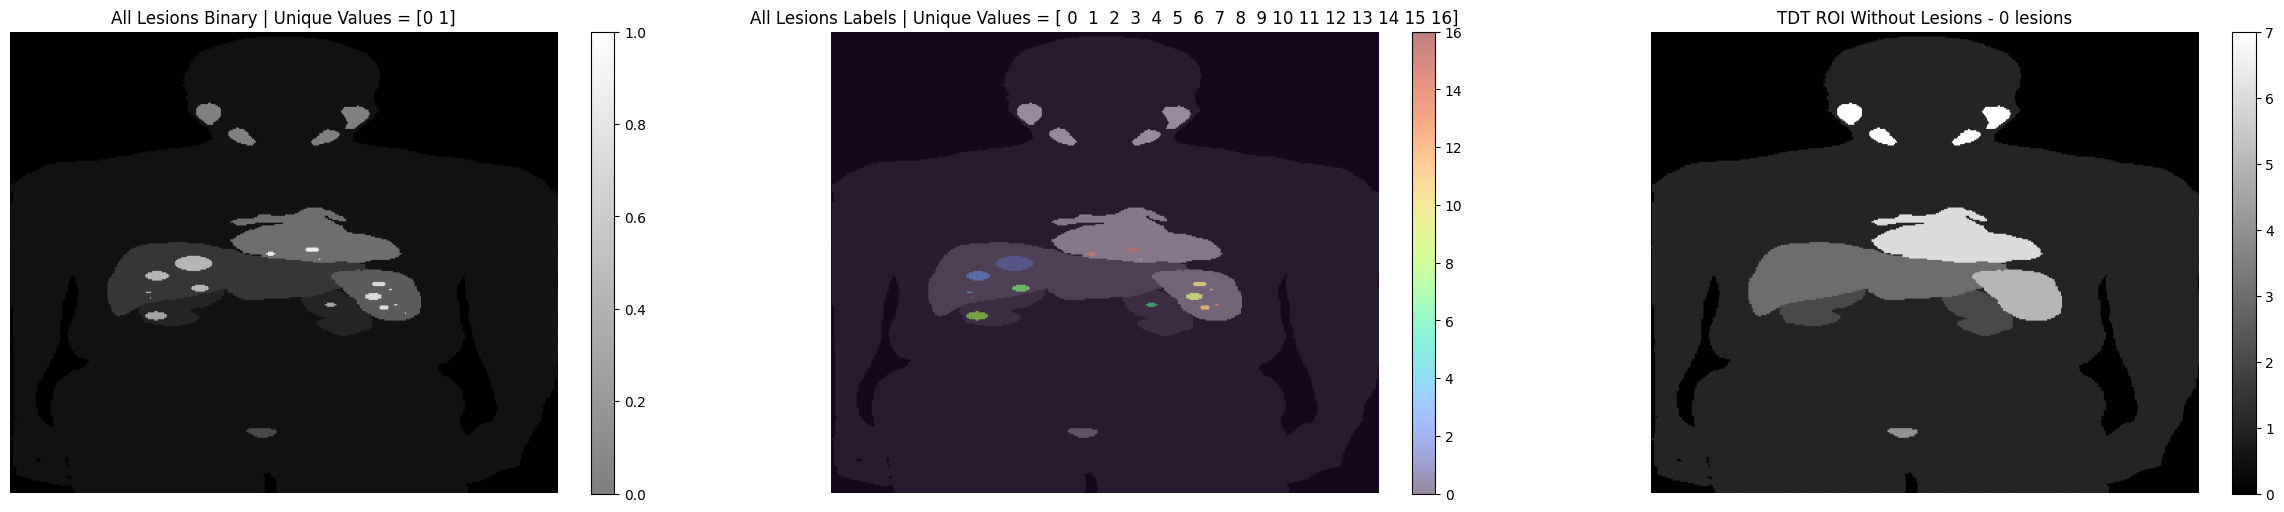

In [5]:
#lesions stuff

lesion_dir = os.path.join(spect_preproc_dir, config['synthetic_lesions']['name']+'_outputs')

all_lesions_binary_path = os.path.join(lesion_dir, 'all_lesions_binary.nii.gz')
all_lesions_labels_path = os.path.join(lesion_dir, 'all_lesions_labels.nii.gz')
tdt_roi_without_lesions_path = os.path.join(lesion_dir, 'tdt_roi_seg_pre_lesions.nii.gz')

all_lesions_binary_img = sitk.ReadImage(all_lesions_binary_path)
all_lesions_binary_array = sitk.GetArrayFromImage(all_lesions_binary_img)

all_lesions_labels_img = sitk.ReadImage(all_lesions_labels_path)
all_lesions_labels_array = sitk.GetArrayFromImage(all_lesions_labels_img)

tdt_roi_without_lesions_img = sitk.ReadImage(tdt_roi_without_lesions_path)
tdt_roi_without_lesions_array = sitk.GetArrayFromImage(tdt_roi_without_lesions_img)

plt.figure(figsize=(30, 6))
plt.subplot(1, 3, 1)
plt.imshow(np.max(tdt_roi_without_lesions_array,axis=1)[::-1],cmap='gray',aspect='auto')
plt.imshow(np.max(all_lesions_binary_array,axis=1)[::-1], cmap='gray', aspect='auto',alpha=0.5) # Max projection along y-axis
plt.title('All Lesions Binary | Unique Values = {}'.format(np.unique(all_lesions_binary_array)))
plt.axis('off')
plt.colorbar()
plt.subplot(1, 3, 2)
plt.imshow(np.max(tdt_roi_without_lesions_array,axis=1)[::-1],cmap='gray',aspect='auto') # Max projection along y-axis
plt.imshow(np.max(all_lesions_labels_array,axis=1)[::-1], cmap='turbo', aspect='auto',alpha=0.5) # Max projection along y-axis
print("All Lesions Labels unique values:", np.unique(all_lesions_labels_array))
plt.title('All Lesions Labels | Unique Values = {}'.format(np.unique(all_lesions_labels_array)))
plt.axis('off')
plt.colorbar()
plt.subplot(1, 3, 3)
plt.imshow(np.max(tdt_roi_without_lesions_array,axis=1)[::-1], cmap='gray', aspect='auto') # Max projection along y-axis
plt.title('TDT ROI Without Lesions - 0 lesions')
plt.axis('off')
plt.colorbar()


['kidney', 'liver', 'prostate', 'spleen', 'heart', 'salivary_glands', 'synthetic_lesion', 'body']
Loading TAC bins for ROI: kidney
Loading TAC bins for ROI: liver
Loading TAC bins for ROI: prostate
Loading TAC bins for ROI: spleen
Loading TAC bins for ROI: heart
Loading TAC bins for ROI: salivary_glands
Loading TAC bins for ROI: synthetic_lesion
Loading TAC bins for ROI: body


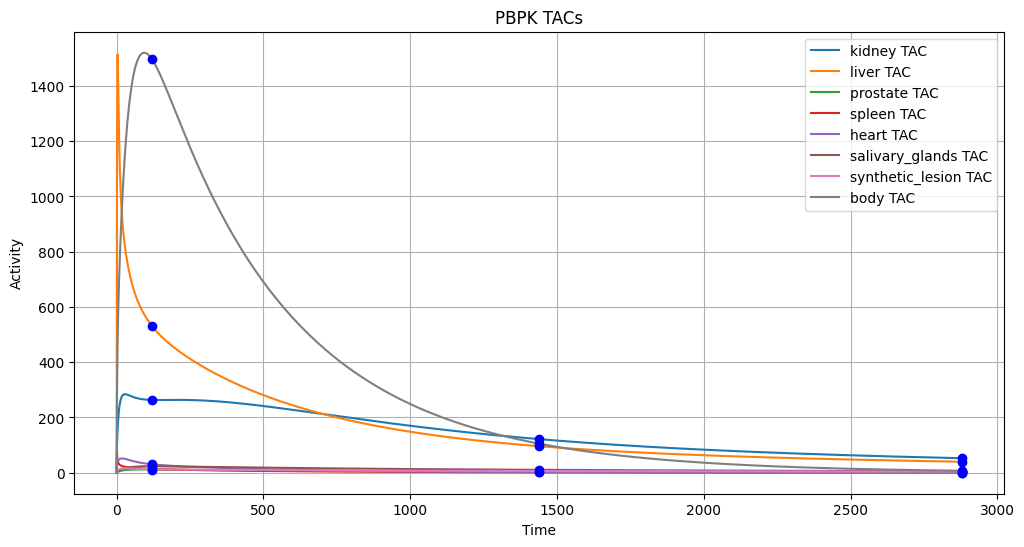

In [6]:
def load_tac_bins(roi, base_path, pbpk_prefix):
    roi = roi.lower()
    t  = np.fromfile(os.path.join(base_path, f"{pbpk_prefix}_{roi}_TAC_time.bin"), dtype=np.float32)
    act  = np.fromfile(os.path.join(base_path, f"{pbpk_prefix}_{roi}_TAC_values.bin"), dtype=np.float32)
    t_s = np.fromfile(os.path.join(base_path, f"{pbpk_prefix}_{roi}_sample_times.bin"), dtype=np.float32)
    act_s = np.fromfile(os.path.join(base_path, f"{pbpk_prefix}_{roi}_sample_values.bin"), dtype=np.float32)
    return t, act, t_s, act_s


pbpk_subdir = config["subdir_names"]["pbpk"]
pbpk_params = config["pbpk"]
pbpk_prefix = pbpk_params["name"]

rois = config['spect_preprocessing']['roi_subset']
rois_copy = rois.copy() # Make a copy of the original list
rois_copy.append('synthetic_lesion')
rois_copy.append('body')
print(rois_copy)

base_path = pbpk_dir

pbpk_tacs = {}   
for roi in rois_copy:
    print(f"Loading TAC bins for ROI: {roi}")
    t, act, t_s, act_s = load_tac_bins(roi, base_path, pbpk_prefix)
    pbpk_tacs[roi] = {
        "t": t,
        "act": act,
        "t_s": t_s,
        "act_s": act_s
    }
    
    
plt.figure(figsize=(12, 6))
for roi in rois_copy:
    plt.plot(pbpk_tacs[roi]['t'], pbpk_tacs[roi]['act'], label=f'{roi} TAC')
    plt.plot(pbpk_tacs[roi]['t_s'], pbpk_tacs[roi]['act_s'], 'bo')
plt.xlabel('Time')
plt.ylabel('Activity')
plt.title('PBPK TACs')
plt.grid()
plt.legend()
plt.show()

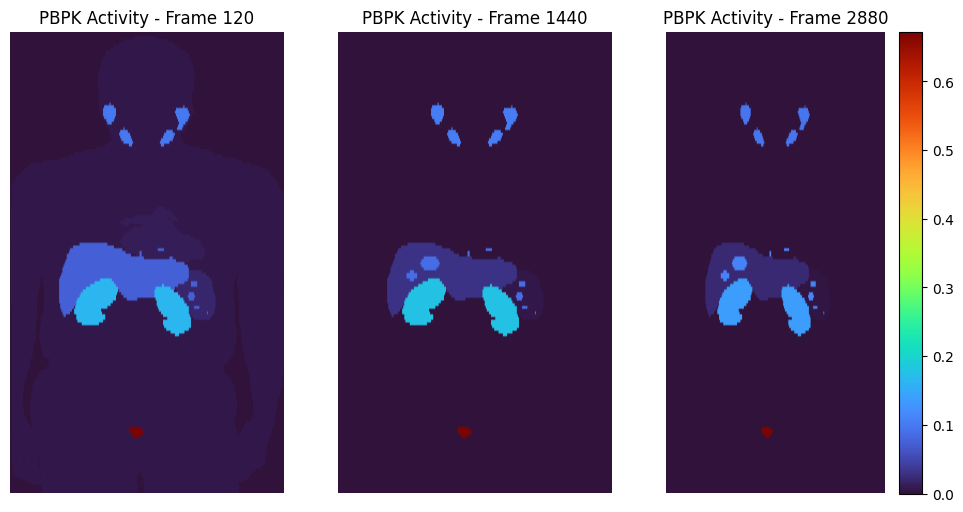

In [7]:
# PBPK stuff

frames = config['pbpk']['FrameStartTimes']


#activtiy maps for each frame
plt.figure(figsize=(len(frames)*4, 6))
plt.subplot(1,len(frames),1)
shape_adjusted = (168, tdt_roi_shape[1]//2, tdt_roi_shape[2]//2)
for f in frames:
    path = os.path.join(pbpk_dir, f'{pbpk_prefix}_{f}_act_av.bin')
    arr = np.fromfile(path, dtype=np.float32).reshape(shape_adjusted)
    
    plt.subplot(1,len(frames),frames.index(f)+1)
    plt.imshow(np.max(arr,axis=1)[::-1], cmap='turbo',aspect='auto')
    plt.title(f'PBPK Activity - Frame {f}')
    plt.axis('off')
plt.colorbar()
plt.show()
    


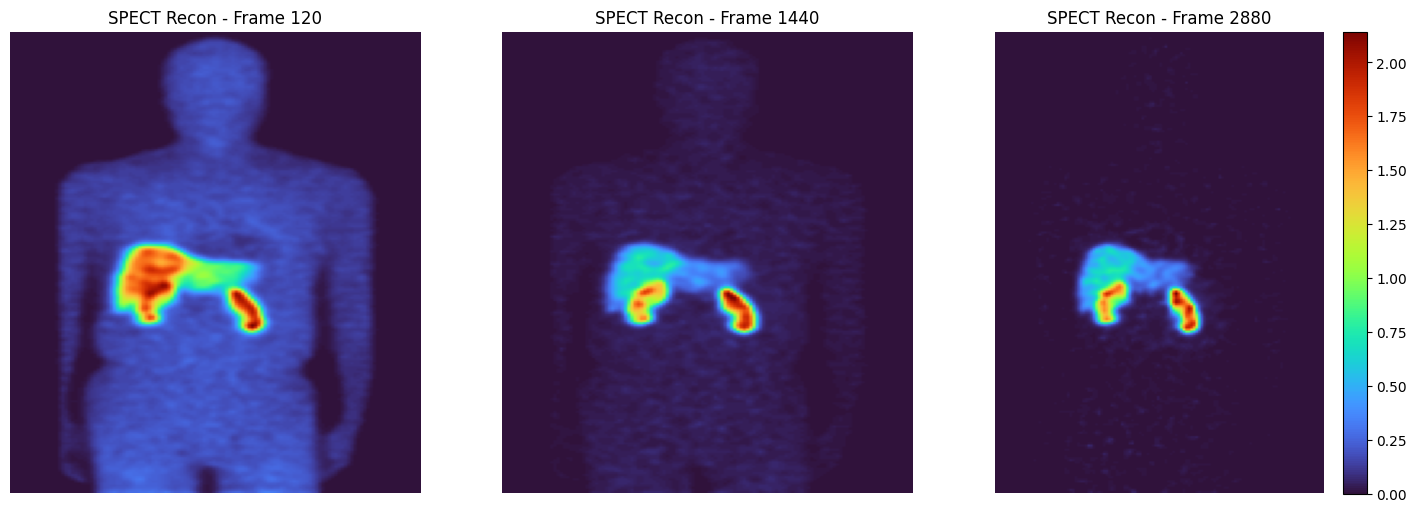

In [ ]:
# SPECT Recon images
plt.figure(figsize=(len(frames)*6, 6))
plt.subplot(1,len(frames),1)

for f in frames:
    path = os.path.join(spect_sim_dir, f'{spect_sim_prefix}_{f}min.nii.gz')
    img = sitk.ReadImage(path)
    arr = sitk.GetArrayFromImage(img)
    plt.subplot(1,len(frames),frames.index(f)+1)
    plt.imshow(np.sum(arr, axis=1)[::-1], cmap='turbo', aspect='auto') # Max projection along y-axis
    plt.title(f'SPECT Recon - Frame {f}')
    plt.axis('off')

plt.colorbar()
plt.show()



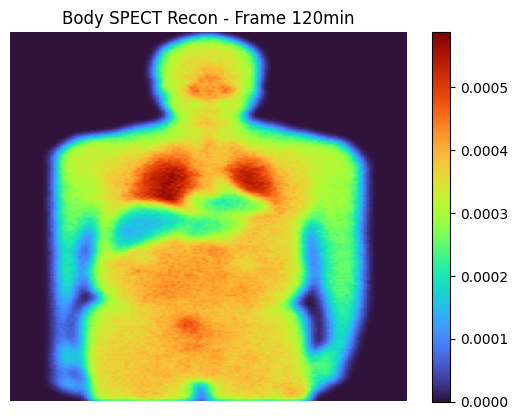

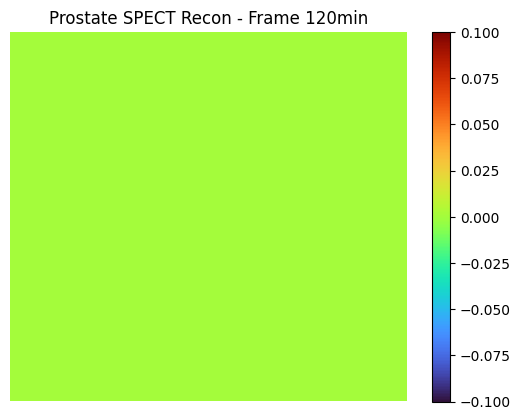

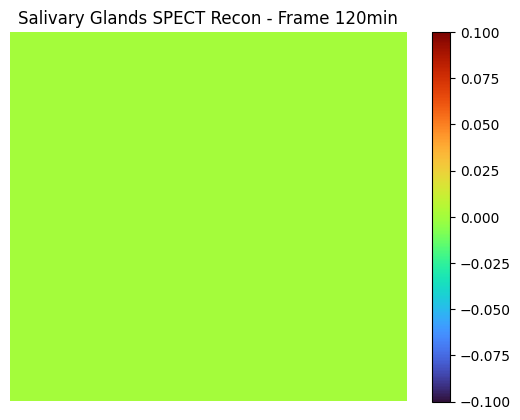

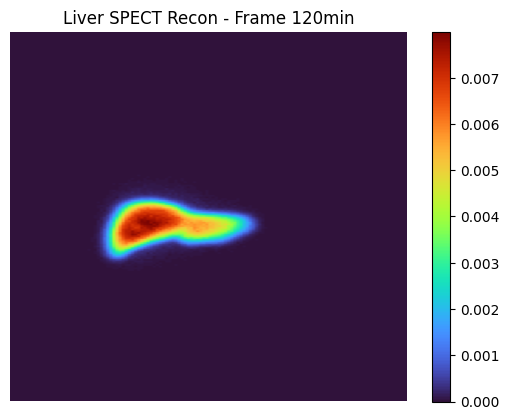

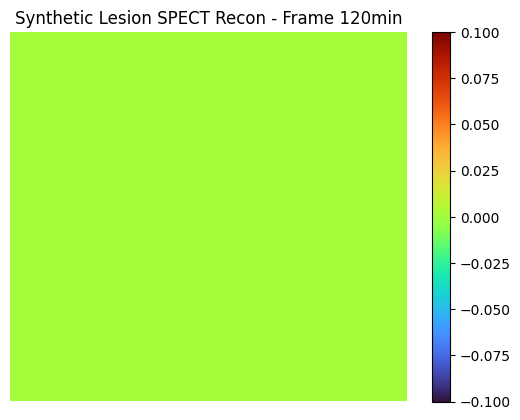

In [27]:
pros_path = '/home/jhubadmin/Theranostic-Virtual-Patient-Pipeline/full_lesions_test_CT_0/spect_simulation_outputs/spect_simulation_prostate_tot_w2.a00'
salg_path = '/home/jhubadmin/Theranostic-Virtual-Patient-Pipeline/full_lesions_test_CT_0/spect_simulation_outputs/spect_simulation_salivary_glands_tot_w2.a00'
body_path = '/home/jhubadmin/Theranostic-Virtual-Patient-Pipeline/full_lesions_test_CT_0/spect_simulation_outputs/spect_simulation_body_tot_w2.a00'
liver_path= '/home/jhubadmin/Theranostic-Virtual-Patient-Pipeline/full_lesions_test_CT_0/spect_simulation_outputs/spect_simulation_liver_tot_w2.a00'
syn_les_path = '/home/jhubadmin/Theranostic-Virtual-Patient-Pipeline/full_lesions_test_CT_0/spect_simulation_outputs/spect_simulation_synthetic_lesion_tot_w2.a00'

shape = (64,219,128)

photopeak = np.fromfile(body_path, dtype=np.float32)
body_arr = (torch.tensor(photopeak.reshape(shape)))
plt.imshow(body_arr[0], cmap='turbo', aspect='auto') # Max projection along y-axis
plt.title('Body SPECT Recon - Frame 120min')
plt.axis('off')
plt.colorbar()
plt.show()

photopeak = np.fromfile(pros_path, dtype=np.float32)
pros_arr = (torch.tensor(photopeak.reshape(shape)))
plt.imshow(pros_arr[0], cmap='turbo', aspect='auto') # Max projection along y-axis
plt.title('Prostate SPECT Recon - Frame 120min')
plt.axis('off')
plt.colorbar()
plt.show()



photopeak = np.fromfile(salg_path, dtype=np.float32)
salg_arr = (torch.tensor(photopeak.reshape(shape)))
plt.imshow(salg_arr[0], cmap='turbo', aspect='auto') # Max projection along y-axis
plt.title('Salivary Glands SPECT Recon - Frame 120min')
plt.axis('off')
plt.colorbar()
plt.show()


photopeak = np.fromfile(liver_path, dtype=np.float32)
liver_arr = (torch.tensor(photopeak.reshape(shape)))
plt.imshow(liver_arr[0], cmap='turbo', aspect='auto') # Max projection along y-axis
plt.title('Liver SPECT Recon - Frame 120min')
plt.axis('off')
plt.colorbar()
plt.show()

photopeak = np.fromfile(syn_les_path, dtype=np.float32)
syn_les_arr = (torch.tensor(photopeak.reshape(shape)))
plt.imshow(syn_les_arr[0], cmap='turbo', aspect='auto') # Max projection along y-axis
plt.title('Synthetic Lesion SPECT Recon - Frame 120min')
plt.axis('off') 
plt.colorbar()
plt.show()

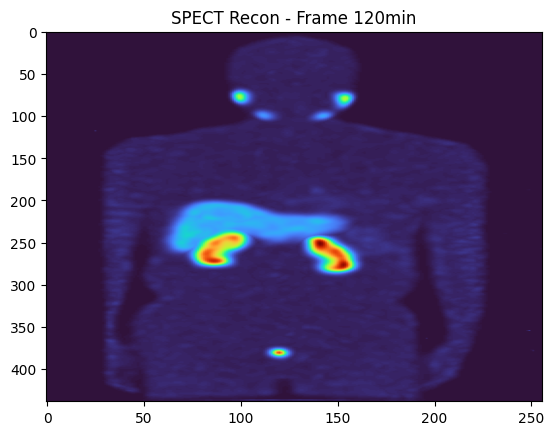

In [9]:
path = '/home/jhubadmin/Theranostic-Virtual-Patient-Pipeline/20_patient_dataset_feb_2026/TDT_Output__CT_1/spect_simulation_outputs/spect_simulation_120min.nii'

img = sitk.ReadImage(path)
arr = sitk.GetArrayFromImage(img)

plt.imshow(np.max(arr, axis=1)[::-1], cmap='turbo', aspect='auto') # Max projection along y-axis
plt.title('SPECT Recon - Frame 120min') 
plt.show()